# IMPORTING REQUIRED MODULES

In [1]:
!pip install optuna

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn
from sklearn.preprocessing import MinMaxScaler, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split
import optuna
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Read Data Set

In [3]:
df=pd.read_csv("EV Charging Behavior Dataset.csv")

In [4]:
df

,User_ID,Age,City_Tier,EV_Type,Battery_Capacity_kWh,Charging_Sessions_Per_Month,Avg_Charge_Cost,Distance_Travelled_Per_Month,Income_Level,Loan_Taken,Missed_Payments_Last_6M,Tenure_Months,Charging_Location_Type,App_Usage_Score,Charger_Working_Status,Charging_Time_Minutes,High_Default_Risk,Charging_Efficiency_Index
0,1,59,Tier3,5KW,40.7,19,325.10,1702,Low,0,2,1,Public,1,Working,58.5,0,100.00
1,2,49,Tier5,5KW,31.7,9,439.97,2377,High,0,0,1,Highway,7,Working,47.0,0,96.36
2,3,35,Tier5,5KW,36.8,24,309.80,1905,Low,0,5,6,Highway,4,Working,53.5,1,100.00
3,4,63,Tier5,2KW,38.5,32,353.90,2074,Medium,0,1,31,Highway,1,Not Working,112.0,1,57.96
4,5,28,Tier1,5KW,33.2,8,597.43,1212,Medium,0,2,24,Private,6,Working,58.0,0,84.56
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18941,18942,54,Tier5,2KW,38.0,23,420.80,938,High,0,0,16,Highway,8,Working,58.0,0,100.00
18942,18943,47,Tier3,5KW,28.6,29,555.51,1289,High,1,1,28,Highway,1,Working,39.8,1,100.00
18943,18944,59,Tier2,5KW,28.6,17,500.97,577,Medium,0,5,15,Private,3,Working,34.3,0,100.00
18944,18945,64,Tier2,4KW,42.3,30,417.63,2255,Low,0,1,18,Highway,2,Working,65.3,1,100.00


### To get the information about the data set

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18946 entries, 0 to 18945
Data columns (total 18 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   User_ID                       18946 non-null  int64  
 1   Age                           18946 non-null  int64  
 2   City_Tier                     18946 non-null  object 
 3   EV_Type                       18946 non-null  object 
 4   Battery_Capacity_kWh          18946 non-null  float64
 5   Charging_Sessions_Per_Month   18946 non-null  int64  
 6   Avg_Charge_Cost               18946 non-null  float64
 7   Distance_Travelled_Per_Month  18946 non-null  int64  
 8   Income_Level                  18946 non-null  object 
 9   Loan_Taken                    18946 non-null  int64  
 10  Missed_Payments_Last_6M       18946 non-null  int64  
 11  Tenure_Months                 18946 non-null  int64  
 12  Charging_Location_Type        18946 non-null  object 
 13  A

### Checking Null Values

In [6]:
df.isnull().sum()

User_ID                         0
Age                             0
City_Tier                       0
EV_Type                         0
Battery_Capacity_kWh            0
Charging_Sessions_Per_Month     0
Avg_Charge_Cost                 0
Distance_Travelled_Per_Month    0
Income_Level                    0
Loan_Taken                      0
Missed_Payments_Last_6M         0
Tenure_Months                   0
Charging_Location_Type          0
App_Usage_Score                 0
Charger_Working_Status          0
Charging_Time_Minutes           0
High_Default_Risk               0
Charging_Efficiency_Index       0
dtype: int64

### Checking Duplicate Values

In [7]:
df.duplicated().sum()

0

### To check and comapre table data frame and information of data set

In [8]:
df.head()

,User_ID,Age,City_Tier,EV_Type,Battery_Capacity_kWh,Charging_Sessions_Per_Month,Avg_Charge_Cost,Distance_Travelled_Per_Month,Income_Level,Loan_Taken,Missed_Payments_Last_6M,Tenure_Months,Charging_Location_Type,App_Usage_Score,Charger_Working_Status,Charging_Time_Minutes,High_Default_Risk,Charging_Efficiency_Index
0,1,59,Tier3,5KW,40.7,19,325.10,1702,Low,0,2,1,Public,1,Working,58.5,0,100.00
1,2,49,Tier5,5KW,31.7,9,439.97,2377,High,0,0,1,Highway,7,Working,47.0,0,96.36
2,3,35,Tier5,5KW,36.8,24,309.80,1905,Low,0,5,6,Highway,4,Working,53.5,1,100.00
3,4,63,Tier5,2KW,38.5,32,353.90,2074,Medium,0,1,31,Highway,1,Not Working,112.0,1,57.96
4,5,28,Tier1,5KW,33.2,8,597.43,1212,Medium,0,2,24,Private,6,Working,58.0,0,84.56


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18946 entries, 0 to 18945
Data columns (total 18 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   User_ID                       18946 non-null  int64  
 1   Age                           18946 non-null  int64  
 2   City_Tier                     18946 non-null  object 
 3   EV_Type                       18946 non-null  object 
 4   Battery_Capacity_kWh          18946 non-null  float64
 5   Charging_Sessions_Per_Month   18946 non-null  int64  
 6   Avg_Charge_Cost               18946 non-null  float64
 7   Distance_Travelled_Per_Month  18946 non-null  int64  
 8   Income_Level                  18946 non-null  object 
 9   Loan_Taken                    18946 non-null  int64  
 10  Missed_Payments_Last_6M       18946 non-null  int64  
 11  Tenure_Months                 18946 non-null  int64  
 12  Charging_Location_Type        18946 non-null  object 
 13  A

In [10]:
df.describe()

,User_ID,Age,Battery_Capacity_kWh,Charging_Sessions_Per_Month,Avg_Charge_Cost,Distance_Travelled_Per_Month,Loan_Taken,Missed_Payments_Last_6M,Tenure_Months,App_Usage_Score,Charging_Time_Minutes,High_Default_Risk,Charging_Efficiency_Index
count,18946.000000,18946.000000,18946.000000,18946.000000,18946.000000,18946.000000,18946.000000,18946.000000,18946.000000,18946.000000,18946.000000,18946.000000,18946.000000
mean,9473.500000,42.919930,35.027890,19.496358,450.124728,1399.960044,0.408266,2.489866,24.096749,5.510767,62.940257,0.443999,87.653957
std,5469.383436,12.915867,10.047099,8.656905,120.149182,635.388130,0.491526,1.701978,13.583756,2.870352,32.274571,0.496867,25.041681
min,1.000000,21.000000,-8.000000,5.000000,-85.560000,300.000000,0.000000,0.000000,1.000000,1.000000,-14.100000,0.000000,0.000000
25%,4737.250000,32.000000,28.300000,12.000000,370.190000,848.250000,0.000000,1.000000,12.000000,3.000000,43.100000,0.000000,90.360000
50%,9473.500000,43.000000,35.100000,19.000000,449.640000,1399.500000,0.000000,2.000000,24.000000,6.000000,55.600000,0.000000,100.000000
75%,14209.750000,54.000000,41.900000,27.000000,530.467500,1951.000000,1.000000,4.000000,36.000000,8.000000,71.000000,1.000000,100.000000
max,18946.000000,65.000000,72.500000,34.000000,901.220000,2499.000000,1.000000,5.000000,47.000000,10.000000,278.200000,1.000000,100.000000


# EDA to determine the outliers

User_ID


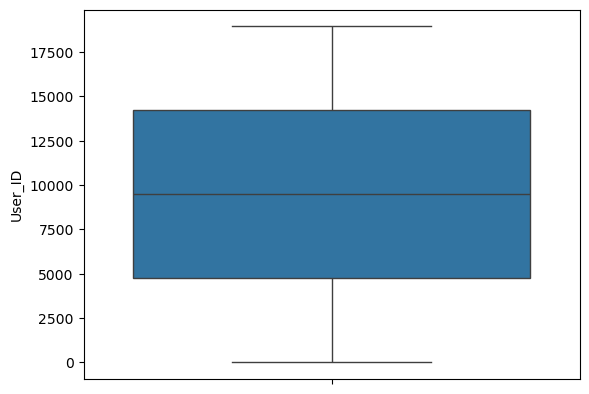

Age


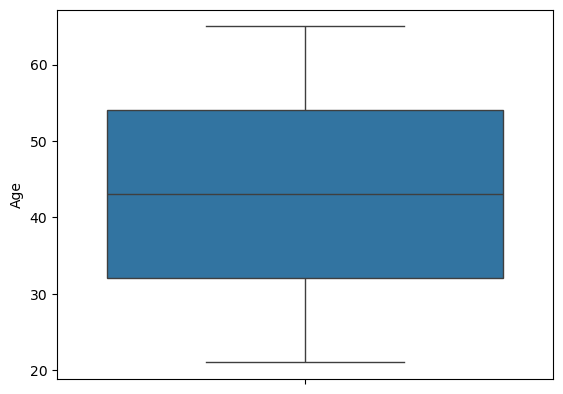

City_Tier


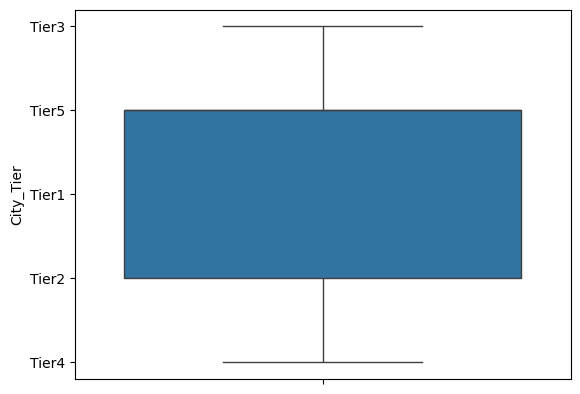

EV_Type


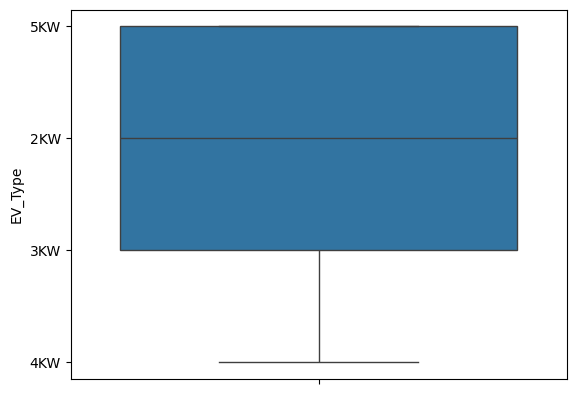

Battery_Capacity_kWh


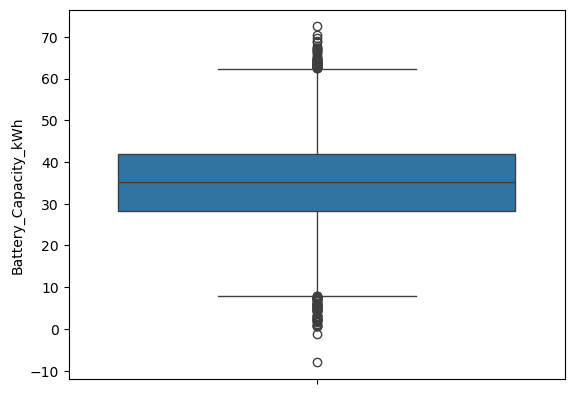

Charging_Sessions_Per_Month


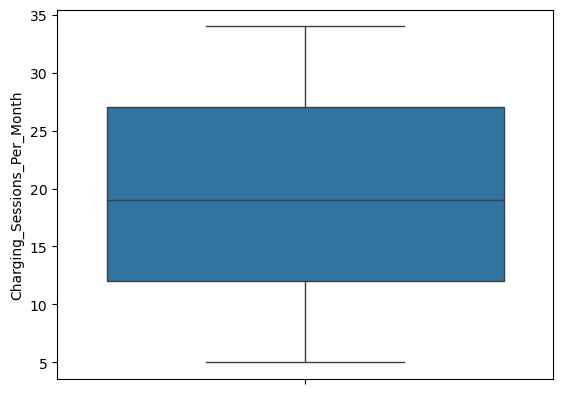

Avg_Charge_Cost


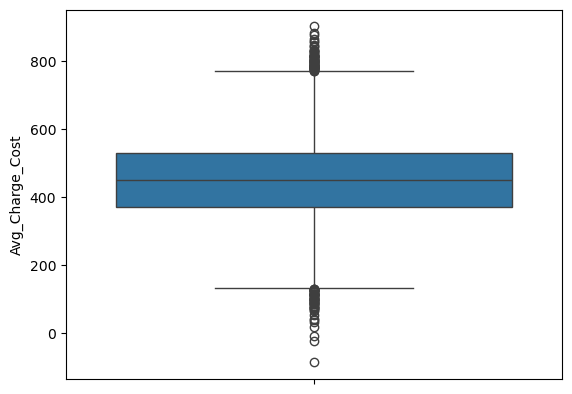

Distance_Travelled_Per_Month


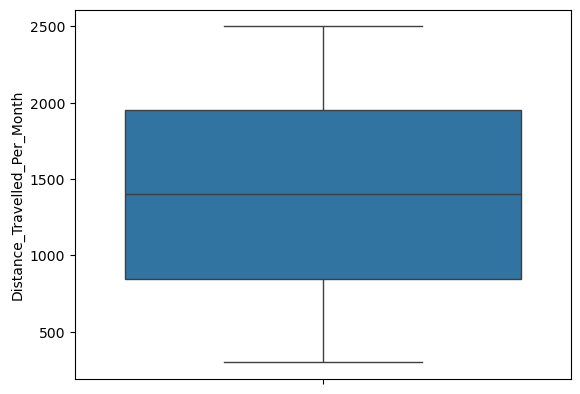

Income_Level


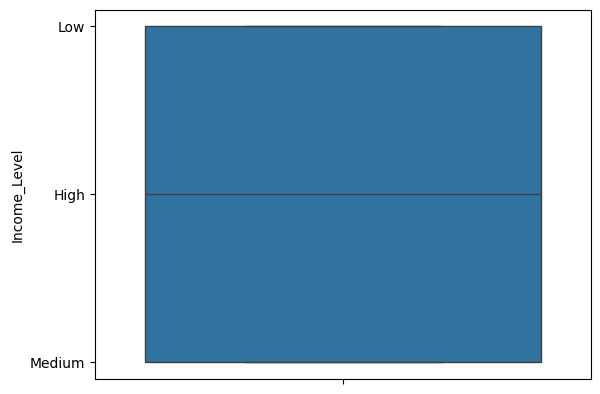

Loan_Taken


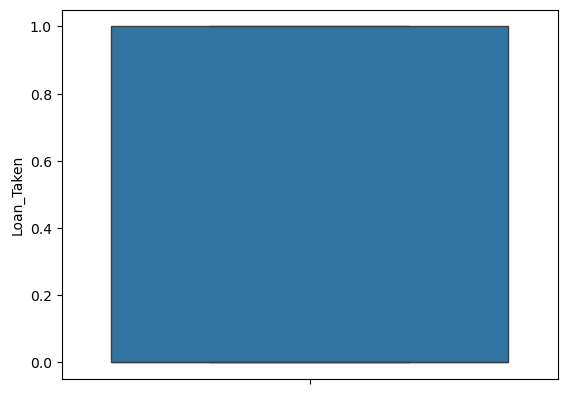

Missed_Payments_Last_6M


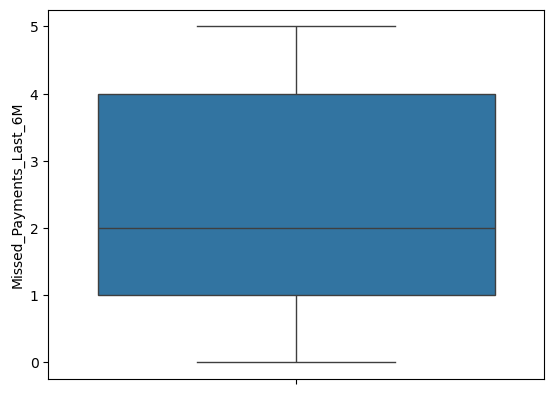

Tenure_Months


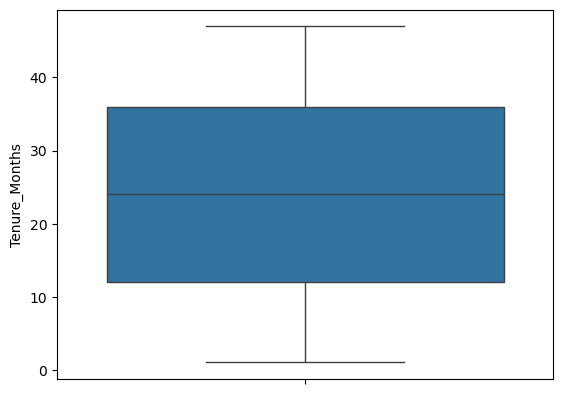

Charging_Location_Type


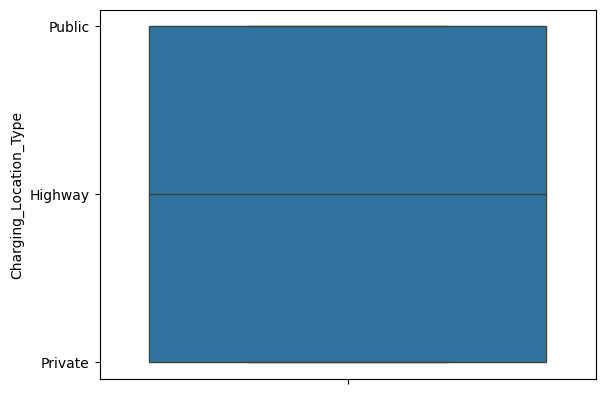

App_Usage_Score


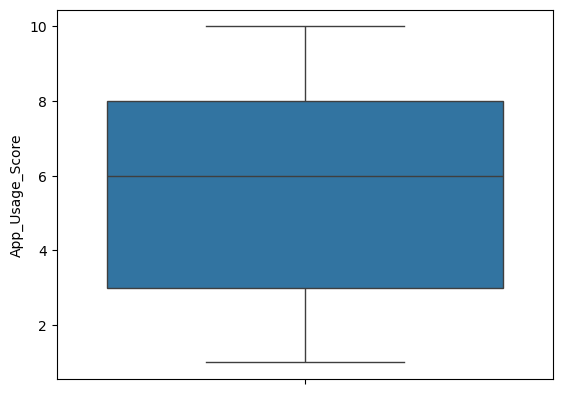

Charger_Working_Status


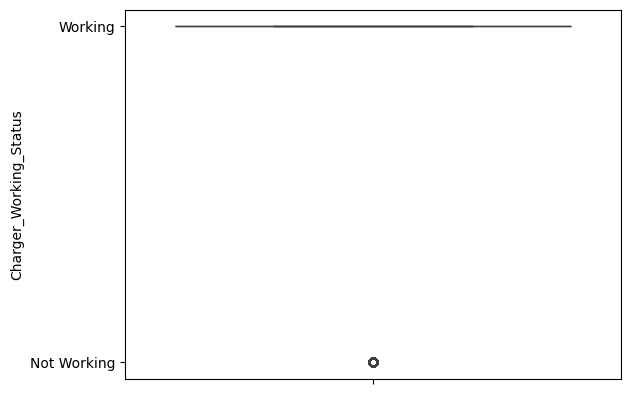

Charging_Time_Minutes


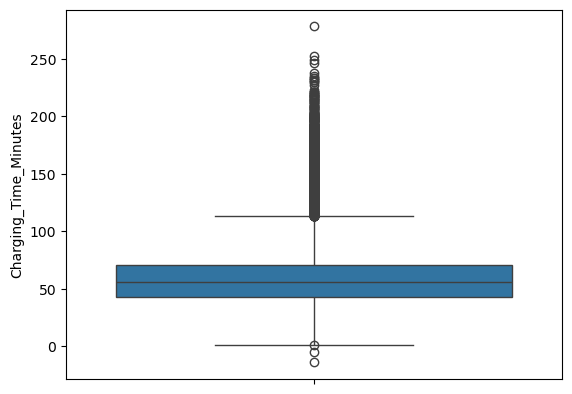

Charging_Efficiency_Index


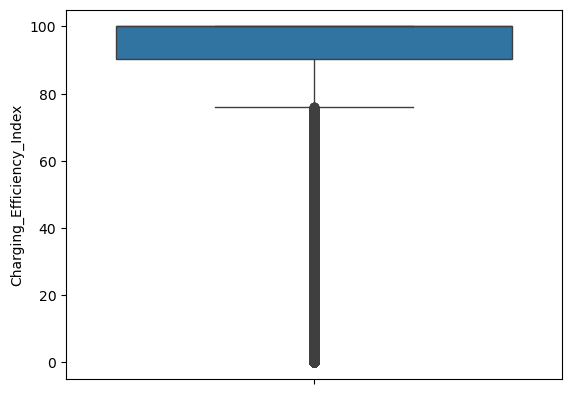

In [36]:
for i in fv.columns.values:
    print(i)
    sns.boxplot( fv[i])
    plt.show()

# Get the Target Column and named it as Class Variable - cv

In [11]:
cv=df["High_Default_Risk"]

In [13]:
cv

0        0
1        0
2        1
3        1
4        0
        ..
18941    0
18942    1
18943    0
18944    1
18945    0
Name: High_Default_Risk, Length: 18946, dtype: int64

# The remaining columns are named as Feature Variables fv

In [12]:
fv=df.drop("High_Default_Risk",axis=1)

In [14]:
fv

,User_ID,Age,City_Tier,EV_Type,Battery_Capacity_kWh,Charging_Sessions_Per_Month,Avg_Charge_Cost,Distance_Travelled_Per_Month,Income_Level,Loan_Taken,Missed_Payments_Last_6M,Tenure_Months,Charging_Location_Type,App_Usage_Score,Charger_Working_Status,Charging_Time_Minutes,Charging_Efficiency_Index
0,1,59,Tier3,5KW,40.7,19,325.10,1702,Low,0,2,1,Public,1,Working,58.5,100.00
1,2,49,Tier5,5KW,31.7,9,439.97,2377,High,0,0,1,Highway,7,Working,47.0,96.36
2,3,35,Tier5,5KW,36.8,24,309.80,1905,Low,0,5,6,Highway,4,Working,53.5,100.00
3,4,63,Tier5,2KW,38.5,32,353.90,2074,Medium,0,1,31,Highway,1,Not Working,112.0,57.96
4,5,28,Tier1,5KW,33.2,8,597.43,1212,Medium,0,2,24,Private,6,Working,58.0,84.56
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18941,18942,54,Tier5,2KW,38.0,23,420.80,938,High,0,0,16,Highway,8,Working,58.0,100.00
18942,18943,47,Tier3,5KW,28.6,29,555.51,1289,High,1,1,28,Highway,1,Working,39.8,100.00
18943,18944,59,Tier2,5KW,28.6,17,500.97,577,Medium,0,5,15,Private,3,Working,34.3,100.00
18944,18945,64,Tier2,4KW,42.3,30,417.63,2255,Low,0,1,18,Highway,2,Working,65.3,100.00


# Preprocessing 

### Seperate the Numeric Columns 

In [15]:
num_cols=["User_ID","Age","Battery_Capacity_kWh","Charging_Sessions_Per_Month","Avg_Charge_Cost","Distance_Travelled_Per_Month","Loan_Taken" ,"Missed_Payments_Last_6M","Tenure_Months" ,"App_Usage_Score", "Charging_Time_Minutes","Charging_Efficiency_Index"]

### Seperate the object columns

In [16]:
cat_cols=["City_Tier","EV_Type","Income_Level","Charging_Location_Type","Charger_Working_Status"]

# Create two pipelines one is for Numericals and another one is for categorical 

In [17]:
num_pl=Pipeline(steps=[('scaling',MinMaxScaler())]) # MinMaxScaler Preprocessing
cat_pl=Pipeline(steps=[('encoding',OneHotEncoder(drop='first',sparse_output=False))]) #OnHotEncoder Preprocessing

In [18]:
num_pl

Pipeline(steps=[('scaling', MinMaxScaler())])

In [19]:
cat_pl

Pipeline(steps=[('encoding', OneHotEncoder(drop='first', sparse_output=False))])

### To run both num_pipeline and cat_pipeline paralelly use ColumnTransformer

In [20]:
ct=ColumnTransformer(transformers=[('scaler',num_pl,num_cols),
                                   ('encoder',cat_pl,cat_cols)])

In [22]:
ct

ColumnTransformer(transformers=[('scaler',
                                 Pipeline(steps=[('scaling', MinMaxScaler())]),
                                 ['User_ID', 'Age', 'Battery_Capacity_kWh',
                                  'Charging_Sessions_Per_Month',
                                  'Avg_Charge_Cost',
                                  'Distance_Travelled_Per_Month', 'Loan_Taken',
                                  'Missed_Payments_Last_6M', 'Tenure_Months',
                                  'App_Usage_Score', 'Charging_Time_Minutes',
                                  'Charging_Efficiency_Index']),
                                ('encoder',
                                 Pipeline(steps=[('encoding',
                                                  OneHotEncoder(drop='first',
                                                                sparse_output=False))]),
                                 ['City_Tier', 'EV_Type', 'Income_Level',
                                  'Charging_Location_Type',
                                  'Charger_Working_Status'])])

# Final Pipeline - to check with Algorithm

In [23]:
final_pl=Pipeline(steps=[("ct",ct),
                         ("estimator",KNeighborsClassifier(n_neighbors=5))])

In [24]:
final_pl

Pipeline(steps=[('ct',
                 ColumnTransformer(transformers=[('scaler',
                                                  Pipeline(steps=[('scaling',
                                                                   MinMaxScaler())]),
                                                  ['User_ID', 'Age',
                                                   'Battery_Capacity_kWh',
                                                   'Charging_Sessions_Per_Month',
                                                   'Avg_Charge_Cost',
                                                   'Distance_Travelled_Per_Month',
                                                   'Loan_Taken',
                                                   'Missed_Payments_Last_6M',
                                                   'Tenure_Months',
                                                   'App_Usage_Score',
                                                   'Charging_Time_Minutes',
                                                   'Charging_Efficiency_Index']),
                                                 ('encoder',
                                                  Pipeline(steps=[('encoding',
                                                                   OneHotEncoder(drop='first',
                                                                                 sparse_output=False))]),
                                                  ['City_Tier', 'EV_Type',
                                                   'Income_Level',
                                                   'Charging_Location_Type',
                                                   'Charger_Working_Status'])])),
                ('estimator', KNeighborsClassifier())])

### Split the data

In [25]:
### Train Test
x_train,x_test,y_train,y_test=train_test_split(fv,cv,test_size=0.30)

### Train the pipeline with train dataset

In [26]:
final_pl.fit(x_train,y_train)

Pipeline(steps=[('ct',
                 ColumnTransformer(transformers=[('scaler',
                                                  Pipeline(steps=[('scaling',
                                                                   MinMaxScaler())]),
                                                  ['User_ID', 'Age',
                                                   'Battery_Capacity_kWh',
                                                   'Charging_Sessions_Per_Month',
                                                   'Avg_Charge_Cost',
                                                   'Distance_Travelled_Per_Month',
                                                   'Loan_Taken',
                                                   'Missed_Payments_Last_6M',
                                                   'Tenure_Months',
                                                   'App_Usage_Score',
                                                   'Charging_Time_Minutes',
                                                   'Charging_Efficiency_Index']),
                                                 ('encoder',
                                                  Pipeline(steps=[('encoding',
                                                                   OneHotEncoder(drop='first',
                                                                                 sparse_output=False))]),
                                                  ['City_Tier', 'EV_Type',
                                                   'Income_Level',
                                                   'Charging_Location_Type',
                                                   'Charger_Working_Status'])])),
                ('estimator', KNeighborsClassifier())])

In [27]:
y_pred=final_pl.predict(x_test) #Predicted values

In [28]:
y_pred

array([1, 0, 0, ..., 0, 1, 0], dtype=int64)

In [29]:
accuracy_score(y_pred,y_test) # Classification Number Metrics

0.8435960591133005

### Insights from above
#### --> So here is the value 0.843 was not a correct accuracy to predict the Risk
#### --> Also here I only used KNN Classification algorithm because Risk Column is a binary classification column
#### --> To get the best accuracy value (~1) I have to change the algorithm model or have to train the model
#### --> So I choosed Optuna a hyper parameter tuning which can able train the model for better accuracy and can have multiple algorithm models 

# Optuna - Hyper Parameter Tuning 

In [33]:
def objective(trial):
    
    x_train,x_test,y_train,y_test=train_test_split(fv,cv,test_size=0.30)

    classifier_name = trial.suggest_categorical("estimators_",['LR','RFC','DTC','GBT'])

    if classifier_name == 'LR':
        lr_c = trial.suggest_categorical('c',[0.1,0.2])
        lr_solver = trial.suggest_categorical('solver',['lbfgs','liblinear','saga'])
        lr_penalty = trial.suggest_categorical('penalty',['l1','l2'])
        clf = LogisticRegression(C = lr_c,solver = lr_solver, penalty = lr_penalty,max_iter = 1500)

    elif classifier_name == 'DTC':
        dt_criterion = trial.suggest_categorical('criteria',['gini','entropy'])
        dt_max_depth = trial.suggest_int('max_dep',low =2,high =5,step = 1)
        dt_max_feat = trial.suggest_int('max_feat',low = 4,high=5,step = 1)
        clf = DecisionTreeClassifier(criterion= dt_criterion, max_depth= dt_max_depth, max_features= dt_max_feat)

    elif classifier_name == "RFC":
        rf_n_est = trial.suggest_int('n_estimators',low=50,high=200,step=50)
        rf_max_feat = trial.suggest_int('max_feat',low = 4,high = 5,step = 1)
        rf_max_depth = trial.suggest_int('max_dep',low =  2,high = 5, step = 1)
        clf = RandomForestClassifier(n_estimators= rf_n_est, max_depth = rf_max_depth, max_features = rf_max_feat)

    elif classifier_name == "GBT":
        gb_lr = trial.suggest_categorical('learning_rate',[0.1,0.15,0.2])
        gb_n_est = trial.suggest_int('n_estimators',low = 50,high = 150,step = 50)
        clf = GradientBoostingClassifier(learning_rate= gb_lr, n_estimators = gb_n_est)
    final_pl=Pipeline(steps=[("ct",ct),
                         ("estimator",clf)])
    final_pl.fit(x_train,y_train)

    return final_pl.score(x_test,y_test)


study = optuna.create_study(direction = "maximize") ## provide sampler hyperparameter to change the search criteria
study.optimize(objective,n_trials= 10,)
print('Best parameters: ',study.best_params)
print("Best Value :", study.best_value)

[I 2026-04-01 15:57:48,911] A new study created in memory with name: no-name-33cf87ac-f962-43d6-97ff-45f90f87986e
[I 2026-04-01 15:57:50,493] Trial 0 finished with value: 0.9996481351161154 and parameters: {'estimators_': 'GBT', 'learning_rate': 0.2, 'n_estimators': 50}. Best is trial 0 with value: 0.9996481351161154.
[I 2026-04-01 15:57:52,258] Trial 1 finished with value: 0.9919071076706545 and parameters: {'estimators_': 'GBT', 'learning_rate': 0.15, 'n_estimators': 50}. Best is trial 0 with value: 0.9996481351161154.
[I 2026-04-01 15:57:53,631] Trial 2 finished with value: 0.9465165376495426 and parameters: {'estimators_': 'RFC', 'n_estimators': 150, 'max_feat': 5, 'max_dep': 4}. Best is trial 0 with value: 0.9996481351161154.
[I 2026-04-01 15:57:55,552] Trial 3 finished with value: 0.9294510907811401 and parameters: {'estimators_': 'RFC', 'n_estimators': 200, 'max_feat': 5, 'max_dep': 4}. Best is trial 0 with value: 0.9996481351161154.
[I 2026-04-01 15:57:56,563] Trial 4 finished 

Best parameters:  {'estimators_': 'GBT', 'learning_rate': 0.2, 'n_estimators': 50}
Best Value : 0.9996481351161154


In [77]:
GradientBoostingClassifier(learning_rate=0.2,n_estimators=50)

# Final Insight

### --> After using optuna we got risk prediction of 0.999 which is a very good accuracy when compared to before
### --> So the algorithm we used here is Gradient Boosting Classifier 
### ---> Hence the model was trained and well predicted